
=== Матрица детекций: Шапиро ===
          pulse_1  pulse_2
target_1        1        1
target_2        1        1
target_3        1        1

=== Матрица детекций: Случайная ===
          pulse_1  pulse_2
target_1        1        1
target_2        0        1
target_3        1        1

=== Сводная таблица по целям ===
    Цель Время до цели (мс)  Найдено (Шапиро) из n_pulses  Найдено (Случайная) из n_pulses
target_1           0.002000                             2                                2
target_2           0.005000                             2                                1
target_3           0.008000                             2                                2

Порог (abs) = 19.200000; tol_ms = 5.000000e-05 ms
Ложных пиков (только количество): Шапиро = 1; Случайная = 2


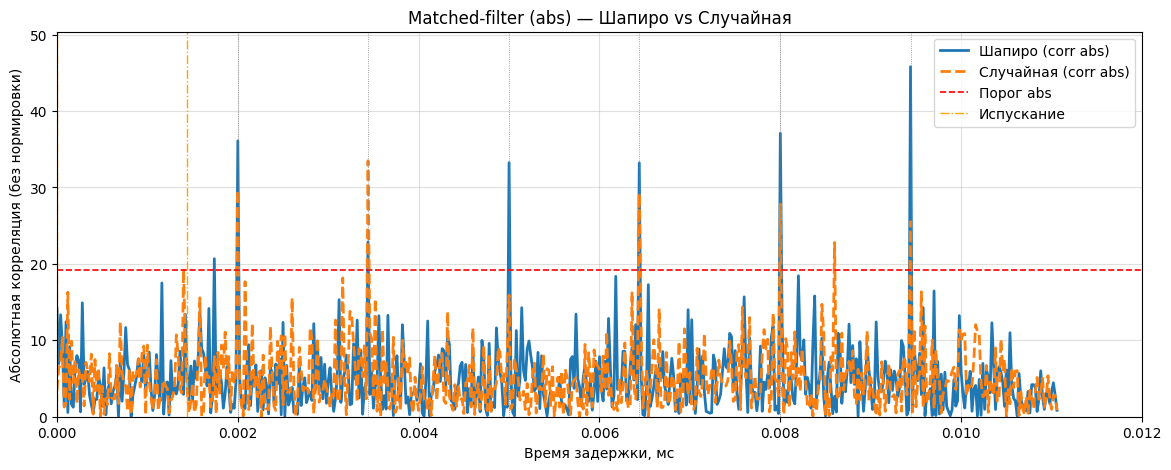

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
import pandas as pd
import os

# -----------------------
# Классы: Sequence, Transmitter, Channel, Receiver, Experiment
# -----------------------

class Sequence:
    def __init__(self, filename=None, length=64, seed=0):
        if filename and os.path.exists(filename):
            s = np.loadtxt(filename, dtype=float)
            if np.min(s) == 0 and np.max(s) == 1:
                s = 2*s - 1
            self.seq = s.astype(float)
        else:
            rng = np.random.default_rng(seed)
            self.seq = (2*rng.integers(0,2,size=length)-1).astype(float)
        self.N = len(self.seq)

class Transmitter:
    def __init__(self, seq, n_pulses, PRI_ms, fs):
        self.seq = np.asarray(seq)
        self.n_pulses = int(n_pulses)
        self.PRI_ms = float(PRI_ms)
        self.fs = fs

    def generate_tx(self):
        pulse_samples = len(self.seq)
        gap_samples = int(round(self.PRI_ms * self.fs / 1000.0))
        if gap_samples < 0:
            gap_samples = 0
        total_samples_per_cycle = pulse_samples + gap_samples
        total_length = self.n_pulses * total_samples_per_cycle
        tx = np.zeros(total_length)
        start_samples = []
        start_times_ms = []
        for k in range(self.n_pulses):
            start = k * total_samples_per_cycle
            tx[start:start + pulse_samples] = self.seq
            start_samples.append(start)
            start_times_ms.append(start / self.fs * 1000.0)
        pulse_duration_ms = pulse_samples / self.fs * 1000.0
        return tx, start_samples, start_times_ms, pulse_duration_ms

class Channel:
    def __init__(self, fs, seed=0):
        self.fs = fs
        self.rng = np.random.default_rng(seed)

    def build_echo_clean(self, tx_signal, delays_ms, amplitudes):
        total_len = len(tx_signal)
        max_delay_samples = int(round(max(delays_ms) * self.fs / 1000.0))
        echo_len = total_len + max_delay_samples + 10
        echo = np.zeros(echo_len)
        nonzero_idx = np.where(tx_signal != 0)[0]
        if len(nonzero_idx) == 0:
            starts = [0]
        else:
            diffs = np.diff(nonzero_idx)
            breaks = np.where(diffs > 1)[0]
            starts = list(nonzero_idx[np.insert(breaks+1, 0, 0)])
        expected_pos_samples = []
        for d_ms, amp in zip(delays_ms, amplitudes):
            d_s = int(round(d_ms * self.fs / 1000.0))
            delayed = np.zeros(echo_len)
            delayed[d_s:d_s + total_len] = tx_signal
            echo += amp * delayed
            for s in starts:
                expected_pos_samples.append(s + d_s)
        expected_pos_samples = sorted(expected_pos_samples)
        return echo, expected_pos_samples

    def add_shared_noise(self, length, noise_std, seed=None):
        if noise_std == 0:
            return np.zeros(length)
        rng = np.random.default_rng(seed)
        return rng.normal(0.0, noise_std, size=length)

class Receiver:
    def __init__(self, ref, fs):
        self.ref = np.asarray(ref)
        self.fs = fs

    def matched_filter_abs(self, recv_signal):
        corr = correlate(recv_signal, self.ref, mode='full')
        corr_abs = np.abs(corr)
        lags = np.arange(-len(self.ref)+1, len(recv_signal))
        lags_ms = lags / self.fs * 1000.0
        return lags_ms, corr_abs

    def find_peaks_by_threshold(self, lags_ms, corr_abs, threshold_abs):
        mask = lags_ms >= 0
        lags_probe = lags_ms[mask]
        corr_probe = corr_abs[mask]

        above = corr_probe >= threshold_abs
        if not np.any(above):
            return np.array([]), np.array([]), []

        idx = np.nonzero(above)[0]
        gaps = np.where(np.diff(idx) > 1)[0]
        blocks = []
        start = idx[0]
        for g in gaps:
            end_idx = idx[g]
            blocks.append((start, end_idx))
            start = idx[g+1]
        blocks.append((start, idx[-1]))

        peak_times = []
        peak_vals = []
        segments = []
        for (s, e) in blocks:
            sub = corr_probe[s:e+1]
            i_rel = int(np.argmax(sub))
            i_abs = s + i_rel
            peak_times.append(float(lags_probe[i_abs]))
            peak_vals.append(float(corr_probe[i_abs]))
            segments.append((int(s), int(e)))
        return np.array(peak_times), np.array(peak_vals), segments

class Experiment:
    def __init__(self,
                 sh_file=None, rn_file=None,
                 fs=50e6, n_pulses=5, PRI_ms=0.0008,
                 targets_ms=None, targets_amp=None,
                 noise_std=0.4, threshold_rel=0.25,
                 x_window_ms=0.016, tol_ms=None, seed=12345):
        self.fs = fs
        self.n_pulses = int(n_pulses)
        self.PRI_ms = float(PRI_ms)
        self.targets_ms = targets_ms if targets_ms is not None else [0.002, 0.005, 0.008]
        self.targets_amp = targets_amp if targets_amp is not None else [1.0 for _ in self.targets_ms]
        self.noise_std = float(noise_std)
        self.threshold_rel = float(threshold_rel)
        self.x_window_ms = float(x_window_ms)
        self.seed = int(seed)
        self.tol_ms = tol_ms

        self.sh = Sequence(sh_file, length=64, seed=seed).seq
        self.rn = Sequence(rn_file, length=len(self.sh), seed=seed+1).seq

        self.tx_sh = Transmitter(self.sh, self.n_pulses, self.PRI_ms, self.fs)
        self.tx_rn = Transmitter(self.rn, self.n_pulses, self.PRI_ms, self.fs)

        self.channel = Channel(self.fs, seed=seed+2)
        self.recv_sh = Receiver(self.sh, self.fs)
        self.recv_rn = Receiver(self.rn, self.fs)

    def run(self, plot=True):
        tx_sh, start_samples_sh, start_times_ms_sh, pulse_duration_ms = self.tx_sh.generate_tx()
        tx_rn, _, _, _ = self.tx_rn.generate_tx()

        if self.tol_ms is None:
            self.tol_ms = float(min(pulse_duration_ms/4.0, self.PRI_ms/3.0, 0.00005))

        echo_sh_clean, expected_samples_sh = self.channel.build_echo_clean(tx_sh, self.targets_ms, self.targets_amp)
        echo_rn_clean, expected_samples_rn = self.channel.build_echo_clean(tx_rn, self.targets_ms, self.targets_amp)

        L = max(len(echo_sh_clean), len(echo_rn_clean))
        echo_sh_clean = np.pad(echo_sh_clean, (0, L - len(echo_sh_clean)))
        echo_rn_clean = np.pad(echo_rn_clean, (0, L - len(echo_rn_clean)))

        noise = self.channel.add_shared_noise(L, self.noise_std, seed=self.seed+10)
        recv_sh = echo_sh_clean + noise
        recv_rn = echo_rn_clean + noise

        energy_sh = np.sum(self.sh**2)
        energy_rn = np.sum(self.rn**2)
        theoretical_max_sh = self.n_pulses * max(self.targets_amp) * energy_sh
        theoretical_max_rn = self.n_pulses * max(self.targets_amp) * energy_rn
        global_theoretical_max = max(theoretical_max_sh, theoretical_max_rn)
        threshold_abs = self.threshold_rel * global_theoretical_max

        lags_sh_ms, corr_sh = self.recv_sh.matched_filter_abs(recv_sh)
        lags_rn_ms, corr_rn = self.recv_rn.matched_filter_abs(recv_rn)

        peak_times_sh, peak_vals_sh, segs_sh = self.recv_sh.find_peaks_by_threshold(lags_sh_ms, corr_sh, threshold_abs)
        peak_times_rn, peak_vals_rn, segs_rn = self.recv_rn.find_peaks_by_threshold(lags_rn_ms, corr_rn, threshold_abs)

        expected_times_per_target = []
        for ti in range(len(self.targets_ms)):
            expected_times = [start_times_ms_sh[k] + self.targets_ms[ti] for k in range(self.n_pulses)]
            expected_times_per_target.append(expected_times)
        expected_ms_all = np.array(sorted([t for sub in expected_times_per_target for t in sub]))

        def classify_peaks(found_peaks_ms, expected_ms_all, tol_ms):
            true_count = 0
            false_count = 0
            for p in found_peaks_ms:
                if np.any(np.abs(p - expected_ms_all) <= tol_ms):
                    true_count += 1
                else:
                    false_count += 1
            return int(true_count), int(false_count)

        true_sh, false_sh = classify_peaks(peak_times_sh, expected_ms_all, self.tol_ms)
        true_rn, false_rn = classify_peaks(peak_times_rn, expected_ms_all, self.tol_ms)

        n_targets = len(self.targets_ms)
        detect_matrix_sh = np.zeros((n_targets, self.n_pulses), dtype=int)
        detect_matrix_rn = np.zeros((n_targets, self.n_pulses), dtype=int)
        for ti in range(n_targets):
            for k in range(self.n_pulses):
                t_expected = expected_times_per_target[ti][k]
                if np.any(np.abs(peak_times_sh - t_expected) <= self.tol_ms):
                    detect_matrix_sh[ti, k] = 1
                if np.any(np.abs(peak_times_rn - t_expected) <= self.tol_ms):
                    detect_matrix_rn[ti, k] = 1

        col_names = [f"pulse_{k+1}" for k in range(self.n_pulses)]
        df_sh_matrix = pd.DataFrame(detect_matrix_sh, index=[f"target_{i+1}" for i in range(n_targets)], columns=col_names)
        df_rn_matrix = pd.DataFrame(detect_matrix_rn, index=[f"target_{i+1}" for i in range(n_targets)], columns=col_names)
        hits_sh = df_sh_matrix.sum(axis=1).astype(int)
        hits_rn = df_rn_matrix.sum(axis=1).astype(int)
        df_summary = pd.DataFrame({
            "Цель": [f"target_{i+1}" for i in range(n_targets)],
            "Время до цели (мс)": [f"{t:.6f}" for t in self.targets_ms],
            "Найдено (Шапиро) из n_pulses": hits_sh.values,
            "Найдено (Случайная) из n_pulses": hits_rn.values
        })

        # Вывод результатов
        print("\n=== Матрица детекций: Шапиро ===")
        print(df_sh_matrix.to_string())
        print("\n=== Матрица детекций: Случайная ===")
        print(df_rn_matrix.to_string())
        print("\n=== Сводная таблица по целям ===")
        print(df_summary.to_string(index=False))
        print(f"\nПорог (abs) = {threshold_abs:.6f}; tol_ms = {self.tol_ms:.6e} ms")
        print(f"Ложных пиков (только количество): Шапиро = {false_sh}; Случайная = {false_rn}")

        if plot:
            plt.figure(figsize=(14,5))
            mask_sh = (lags_sh_ms >= 0) & (lags_sh_ms <= self.x_window_ms)
            mask_rn = (lags_rn_ms >= 0) & (lags_rn_ms <= self.x_window_ms)
            plt.plot(lags_sh_ms[mask_sh], corr_sh[mask_sh], label='Шапиро (corr abs)', linewidth=2)
            plt.plot(lags_rn_ms[mask_rn], corr_rn[mask_rn], '--', label='Случайная (corr abs)', linewidth=2)
            plt.axhline(threshold_abs, color='red', linestyle='--', linewidth=1.2, label='Порог abs')
            for k, t in enumerate(start_times_ms_sh):
                if t <= self.x_window_ms:
                    plt.axvline(t, color='orange', linestyle='-.', linewidth=1.0, label='Испускание' if k==0 else "")
            for t in expected_ms_all:
                if t <= self.x_window_ms:
                    plt.axvline(t, color='gray', linestyle=':', linewidth=0.6)
            plt.xlim(0, self.x_window_ms)
            ymax = max(corr_sh[mask_sh].max() if mask_sh.any() else 0.0,
                       corr_rn[mask_rn].max() if mask_rn.any() else 0.0,
                       threshold_abs)
            plt.ylim(0, ymax * 1.10 if ymax > 0 else 1.0)
            plt.xlabel("Время задержки, мс")
            plt.ylabel("Абсолютная корреляция (без нормировки)")
            plt.title("Matched-filter (abs) — Шапиро vs Случайная")
            plt.grid(True, alpha=0.4)
            plt.legend()
            plt.show()

        return {
            "df_sh_matrix": df_sh_matrix,
            "df_rn_matrix": df_rn_matrix,
            "df_summary": df_summary,
            "false_count_sh": false_sh,
            "false_count_rn": false_rn,
            "peak_times_sh": peak_times_sh,
            "peak_vals_sh": peak_vals_sh,
            "peak_times_rn": peak_times_rn,
            "peak_vals_rn": peak_vals_rn,
            "threshold_abs": threshold_abs,
            "tol_ms": self.tol_ms
        }

# -----------------------
# Настройки (всё можно менять здесь)
# -----------------------
shapiro_file = "../files/shapiro_polynomial_for_radar_experiment.txt"   
random_file = "../files/random_polynomial_for_radar_experiment.txt"     

fs = 50e6              # Гц
n_pulses = 2
PRI_ms = 0.0008        # мс
noise_std = 1
targets_ms = [0.002, 0.005, 0.008]   # мс
targets_amp = [1.0, 1.0, 1.0]
seed = 2025

threshold_rel = 0.3  # доля от теоретического макс.
x_window_ms = 0.012
tol_ms = None          # если None — подбирается автоматически

# -----------------------
# Запуск
# -----------------------
if __name__ == "__main__":
    exp = Experiment(
        sh_file=shapiro_file,
        rn_file=random_file,
        fs=fs,
        n_pulses=n_pulses,
        PRI_ms=PRI_ms,
        targets_ms=targets_ms,
        targets_amp=targets_amp,
        noise_std=noise_std,
        threshold_rel=threshold_rel,
        x_window_ms=x_window_ms,
        tol_ms=tol_ms,
        seed=seed
    )
    results = exp.run(plot=True)
